# Previsão de Dst com LSTM — Versão corrigida (V1.9)

Principais correções em relação à V1.8:
1. **Sem data leakage**: divisão treino/val/teste feita **antes** do scaling; `StandardScaler` ajustado apenas no treino.
2. **Imputação por período**: `ffill`/interpolação não atravessam mais as fronteiras de `train_a/b/c`.
3. **`dropna` nos rótulos** (`shift` cria NaN no fim de cada período).
4. **Pipeline definido uma única vez** e reutilizado na inferência (sem código duplicado).
5. APIs atualizadas (`.ffill()`, `floor("h")`), seeds fixadas, callbacks (`EarlyStopping`, `ModelCheckpoint`, `ReduceLROnPlateau`).
6. Correções menores: `reshape` com `len(XCOLS)`, labels de gráficos, caminhos centralizados.

In [1]:
# Bibliotecas
import json
import pickle
from pathlib import Path
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras import preprocessing
from keras.models import Sequential
from keras.layers import Dense, LSTM
from keras.optimizers import RMSprop
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler

# Reprodutibilidade
SEED = 2024
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Centralize os caminhos aqui (ajuste conforme o ambiente: Colab = "/content")
DATA_DIR = Path("/content")

## Leitura e indexação dos dados

In [2]:
labels_data = pd.read_csv(DATA_DIR / "labels.csv")
satelite_pos = pd.read_csv(DATA_DIR / "satellite_pos.csv")
sunspot = pd.read_csv(DATA_DIR / "sunspots.csv")
solar_wind_data = pd.read_csv(DATA_DIR / "solar_wind.csv")

def set_period_timedelta_index(df: pd.DataFrame) -> pd.DataFrame:
    """Converte `timedelta` e define o MultiIndex (period, timedelta)."""
    df = df.copy()
    df["timedelta"] = pd.to_timedelta(df["timedelta"])
    return df.set_index(["period", "timedelta"])

labels_data = set_period_timedelta_index(labels_data)
sunspot = set_period_timedelta_index(sunspot)
solar_wind_data = set_period_timedelta_index(solar_wind_data)
satelite_pos = set_period_timedelta_index(satelite_pos)  # agora indexado como os demais

# Exploração dos dados

In [3]:
print("Tamanho DST:            ", labels_data.shape)
print("Tamanho pos_satelite:   ", satelite_pos.shape)
print("Tamanho mancha solar:   ", sunspot.shape)
print("Tamanho ventos solares: ", solar_wind_data.shape)

Tamanho DST:             (139872, 1)
Tamanho pos_satelite:    (5828, 6)
Tamanho mancha solar:    (192, 1)
Tamanho ventos solares:  (8392320, 15)


### Labels

In [4]:
labels_data.head()

dst
period  timedelta           
train_a 0 days 00:00:00   -7
        0 days 01:00:00  -10
        0 days 02:00:00  -10
        0 days 03:00:00   -6
        0 days 04:00:00   -2

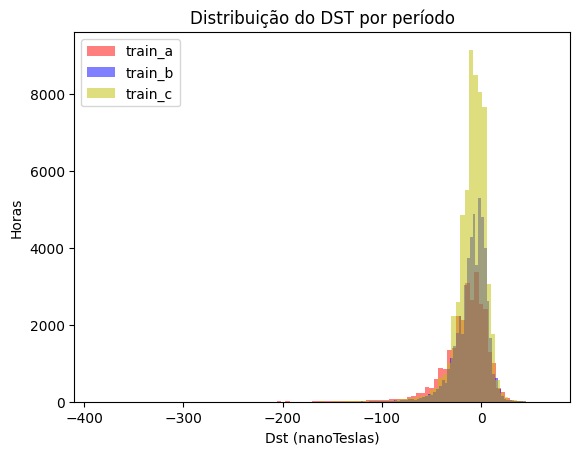

In [5]:
# Histograma do Dst por período (coluna explícita, sem depender do df ter 1 coluna)
fig, ax = plt.subplots()
colors = ["r", "b", "y"]

for i, (period_name, df) in enumerate(labels_data.groupby("period")):
    ax.hist(df["dst"], alpha=0.5, color=colors[i], bins=100, label=period_name)

ax.legend()
ax.set_title("Distribuição do DST por período")
ax.set_xlabel("Dst (nanoTeslas)")
ax.set_ylabel("Horas")
plt.show()

In [6]:
labels_data.groupby("period").describe()

dst                                                    
           count       mean        std    min   25%   50%  75%   max
period                                                              
train_a  28824.0 -16.576707  26.083191 -387.0 -26.0 -12.0 -1.0  65.0
train_b  52584.0  -9.695154  16.443049 -223.0 -17.0  -7.0  1.0  59.0
train_c  58464.0  -9.556325  16.506404 -374.0 -16.0  -7.0  0.0  67.0

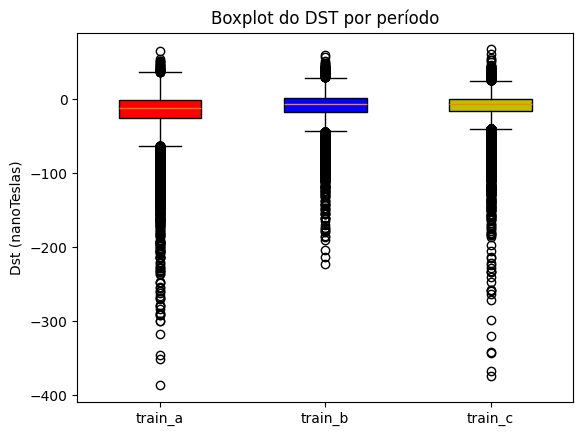

In [7]:
# Boxplot do Dst por período
fig, ax = plt.subplots()
colors = ["r", "b", "y"]
period_names = []
for i, (period_name, df) in enumerate(labels_data.groupby("period")):
    period_names.append(period_name)
    ax.boxplot(df["dst"], positions=[i], widths=[0.5],
               patch_artist=True, boxprops=dict(facecolor=colors[i]))
ax.set_xticks(range(len(period_names)))
ax.set_xticklabels(period_names)  # usa os nomes reais, não hardcoded
ax.set_title("Boxplot do DST por período")
ax.set_ylabel("Dst (nanoTeslas)")
plt.show()

### Solar wind

In [8]:
solar_wind_data.head()

bx_gse  by_gse  bz_gse  theta_gse  phi_gse  bx_gsm  \
period  timedelta                                                             
train_a 0 days 00:00:00   -5.55    3.00    1.25      11.09   153.37   -5.55   
        0 days 00:01:00   -5.58    3.16    1.17      10.10   151.91   -5.58   
        0 days 00:02:00   -5.15    3.66    0.85       7.87   146.04   -5.15   
        0 days 00:03:00   -5.20    3.68    0.68       6.17   146.17   -5.20   
        0 days 00:04:00   -5.12    3.68    0.49       4.62   145.72   -5.12   

                         by_gsm  bz_gsm  theta_gsm  phi_gsm    bt  density  \
period  timedelta                                                            
train_a 0 days 00:00:00    3.00    1.25      11.09   153.37  6.80     1.53   
        0 days 00:01:00    3.16    1.17      10.10   151.91  6.83     1.69   
        0 days 00:02:00    3.66    0.85       7.87   146.04  6.77     1.97   
        0 days 00:03:00    3.68    0.68       6.17   146.17  6.74     1.97   
        0 days 00:04:00    3.68    0.49       4.62   145.72  6.65     1.77   

                          speed  temperature source  
period  timedelta                                    
train_a 0 days 00:00:00  383.92     110237.0     ac  
        0 days 00:01:00  381.79     123825.0     ac  
        0 days 00:02:00  389.11      82548.0     ac  
        0 days 00:03:00  389.11      82548.0     ac  
        0 days 00:04:00  384.26      94269.0     ac

In [9]:
solar_wind_data.groupby("period").describe().T

period                  train_a       train_b       train_c
bx_gse      count  1.575012e+06  3.084130e+06  3.407290e+06
            mean  -1.781301e+00 -3.088789e-01 -4.619076e-01
            std    4.339212e+00  3.627830e+00  3.245485e+00
            min   -5.463000e+01 -2.937000e+01 -4.546000e+01
            25%   -4.960000e+00 -3.070000e+00 -2.800000e+00
...                         ...           ...           ...
temperature min    1.000000e+04  1.496000e+03  0.000000e+00
            25%    4.364900e+04  3.741400e+04  4.007400e+04
            50%    7.923800e+04  8.552400e+04  7.152100e+04
            75%    1.325500e+05  1.873250e+05  1.310880e+05
            max    6.223700e+06  4.206672e+06  5.751308e+06

[112 rows x 3 columns]

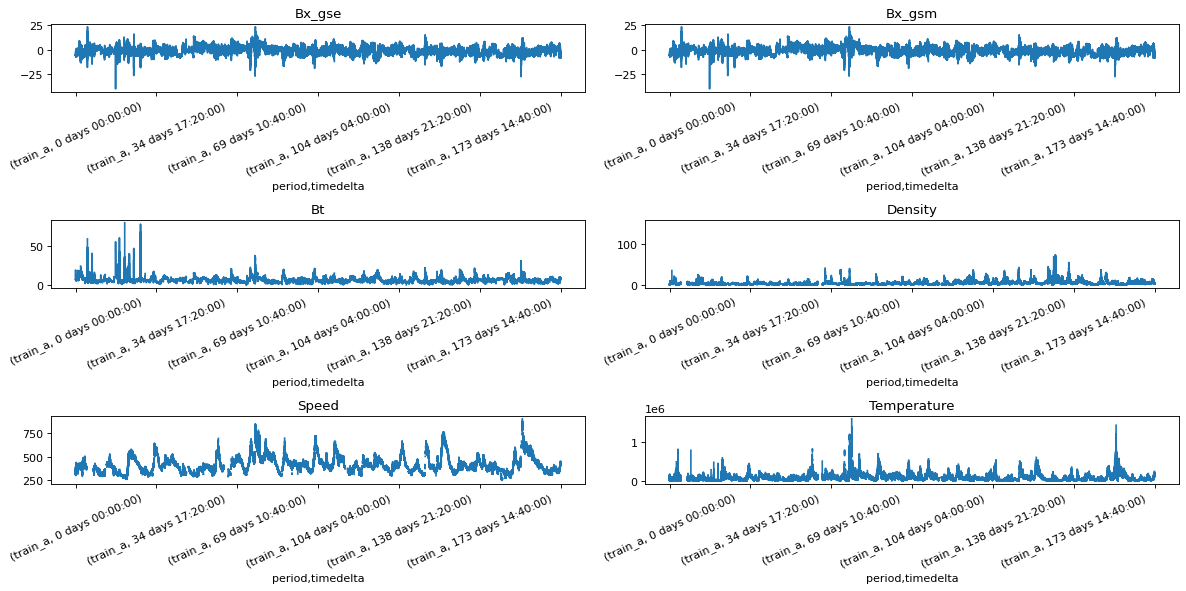

In [10]:
def show_raw_visualization(data: pd.DataFrame, num_rows: int = 1000):
    """Plota cada coluna do DataFrame em um subplot separado.

    A grade se adapta ao número de colunas (a versão antiga era fixa em 3x2
    e quebrava se `cols_to_plot` mudasse).
    """
    n = len(data.columns)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(15, 2.5 * nrows), dpi=80, squeeze=False)
    for i, key in enumerate(data.columns):
        data[key].iloc[:num_rows].plot(
            ax=axes[i // ncols, i % ncols], title=key.capitalize(), rot=25
        )
    # esconde eixos sobrando
    for j in range(n, nrows * ncols):
        axes[j // ncols, j % ncols].set_visible(False)
    plt.tight_layout()

cols_to_plot = ["bx_gse", "bx_gsm", "bt", "density", "speed", "temperature"]
show_raw_visualization(solar_wind_data[cols_to_plot], num_rows=300_000)

In [11]:
# Valores ausentes por coluna
solar_wind_data.isna().sum()

,0
bx_gse,325888
by_gse,325888
bz_gse,325888
theta_gse,325888
phi_gse,326388
bx_gsm,325888
by_gsm,325888
bz_gsm,325888
theta_gsm,325888
phi_gsm,326388


### Sunspot

In [12]:
sunspot.head()

smoothed_ssn
period  timedelta              
train_a 0 days             65.4
        13 days            72.0
        44 days            76.9
        74 days            80.8
        105 days           85.4

In [13]:
sunspot.groupby("period").describe().T

period                 train_a     train_b    train_c
smoothed_ssn count   40.000000   72.000000  80.000000
             mean   136.902500   51.850000  24.313750
             std     34.563168   39.200266  19.020414
             min     65.400000    3.900000   2.200000
             25%    108.375000   15.325000   7.775000
             50%    151.500000   43.150000  20.500000
             75%    164.400000   91.225000  38.525000
             max    175.200000  116.400000  69.500000

### Posição do satélite

> **Nota:** `satelite_pos` não entra como feature do modelo nesta versão (mesmo comportamento da V1.8, agora documentado). Se quiser testá-la como feature, agregue por hora e faça o `join` junto com o sunspot em `build_hourly_features`.

In [14]:
satelite_pos.head()

gse_x_ace  gse_y_ace  gse_z_ace  gse_x_dscovr  \
period  timedelta                                                  
train_a 0 days     1522376.9   143704.6   149496.7           NaN   
        1 days     1525410.9   136108.8   151034.1           NaN   
        2 days     1528484.9   128470.5   152387.7           NaN   
        3 days     1531570.3   120818.4   153561.4           NaN   
        4 days     1534633.1   113178.5   154534.6           NaN   

                   gse_y_dscovr  gse_z_dscovr  
period  timedelta                              
train_a 0 days              NaN           NaN  
        1 days              NaN           NaN  
        2 days              NaN           NaN  
        3 days              NaN           NaN  
        4 days              NaN           NaN

## Correlação entre features

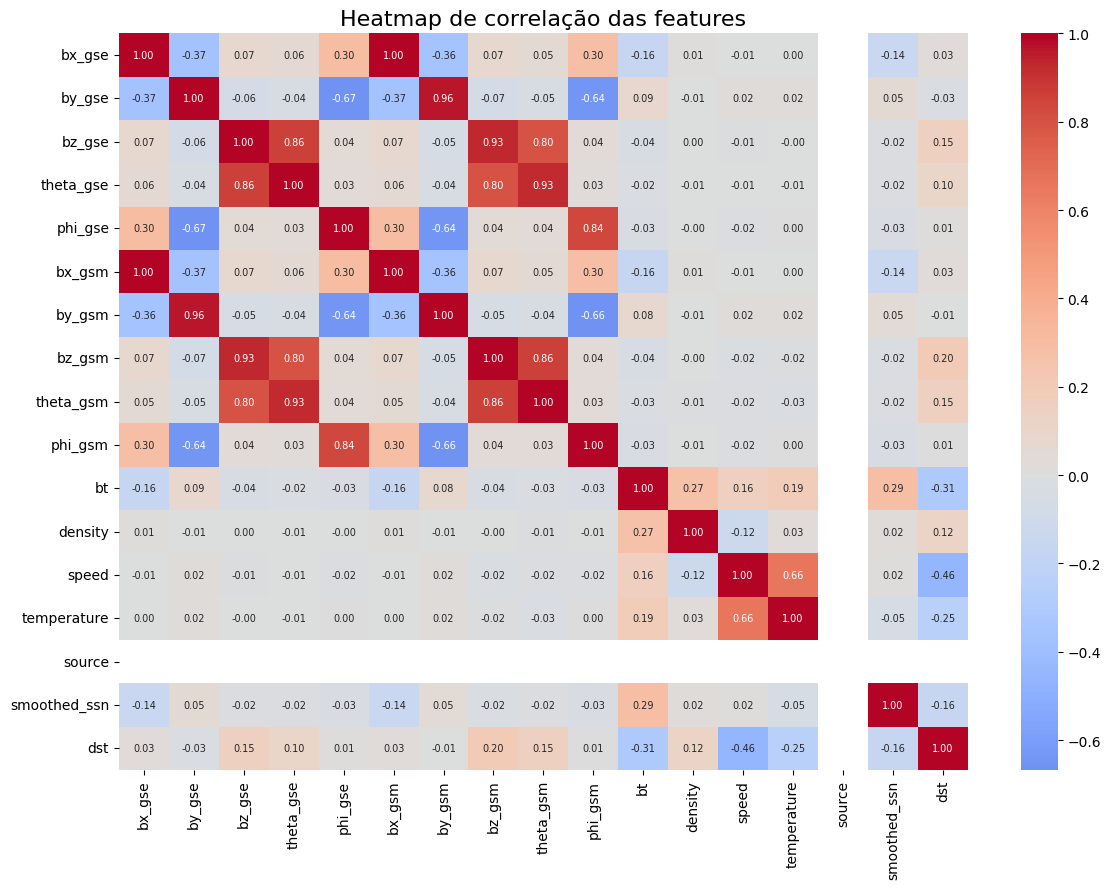

In [15]:
# 'source' é categórica -> converte para numérica apenas para a correlação
sw_num = solar_wind_data.copy()
if sw_num["source"].dtype == object:
    sw_num["source"] = sw_num["source"].map({"ac": 0, "dsc": 1})

corr = (
    sw_num.join(sunspot)
          .join(labels_data)
          .ffill()          # .fillna(method="ffill") está deprecado
          .corr(numeric_only=True)
)

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7})
plt.title("Heatmap de correlação das features", fontsize=16)
plt.tight_layout()
plt.show()

# Pipeline de features (definido UMA vez, usado no treino e na inferência)

Ordem correta para evitar leakage:
1. Agregar por hora e juntar `solar_wind` + `sunspot` (**sem** escalar).
2. Criar rótulos e **dividir** em treino/val/teste.
3. Ajustar o `StandardScaler` **somente no treino** e transformar os três conjuntos.
4. Imputar **por período** (ffill + interpolação não atravessam fronteiras de período).

In [16]:
SOLAR_WIND_FEATURES = [
    "bt", "temperature", "bx_gse", "by_gse", "bz_gse", "speed", "density",
]

XCOLS = (
    [c + "_mean" for c in SOLAR_WIND_FEATURES]
    + [c + "_std" for c in SOLAR_WIND_FEATURES]
    + ["smoothed_ssn"]
)
YCOLS = ["t0", "t1"]


def aggregate_hourly(feature_df: pd.DataFrame, aggs=("mean", "std")) -> pd.DataFrame:
    """Agrega os dados minuto-a-minuto para o piso de cada hora (média e desvio).

    Suporta tanto MultiIndex (period, timedelta) — treino — quanto índice
    TimedeltaIndex simples — inferência. Não modifica o DataFrame recebido.
    """
    feature_df = feature_df.copy()
    if isinstance(feature_df.index, pd.MultiIndex):
        grouper = ["period", feature_df.index.get_level_values(1).floor("h")]
    else:
        if not isinstance(feature_df.index, pd.TimedeltaIndex):
            feature_df.index = pd.to_timedelta(feature_df.index)
        grouper = [feature_df.index.floor("h")]

    agged = feature_df.groupby(grouper).agg(list(aggs))
    agged.columns = ["_".join(c) for c in agged.columns]
    return agged


def build_hourly_features(solar_wind_df: pd.DataFrame,
                          sunspot_df: pd.DataFrame,
                          subset=None) -> pd.DataFrame:
    """Agrega o vento solar por hora e junta com o sunspot (sem escalar)."""
    if subset:
        solar_wind_df = solar_wind_df[subset]
    return aggregate_hourly(solar_wind_df).join(sunspot_df)


def impute_features(feature_df: pd.DataFrame) -> pd.DataFrame:
    """Imputa valores ausentes:
    - `smoothed_ssn`: forward fill
    - demais colunas: interpolação linear

    Se o índice tiver períodos, imputa POR período para não vazar valores
    de um período para o outro (bug da V1.8).
    """
    def _impute(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df["smoothed_ssn"] = df["smoothed_ssn"].ffill()
        return df.interpolate(limit_direction="both")

    if isinstance(feature_df.index, pd.MultiIndex):
        return feature_df.groupby(level="period", group_keys=False).apply(_impute)
    return _impute(feature_df)


def scale_features(feature_df: pd.DataFrame, scaler: StandardScaler) -> pd.DataFrame:
    """Aplica um scaler JÁ ajustado, preservando índice e colunas."""
    return pd.DataFrame(
        scaler.transform(feature_df),
        index=feature_df.index,
        columns=feature_df.columns,
    )


def process_labels(dst: pd.DataFrame) -> pd.DataFrame:
    """t0 = dst(t+1h), t1 = dst(t+2h). O shift cria NaN no fim de cada
    período — remova-os antes de treinar/avaliar (feito na divisão)."""
    y = dst.copy()
    y["t0"] = y.groupby("period")["dst"].shift(-1)
    y["t1"] = y.groupby("period")["dst"].shift(-2)
    return y[YCOLS]

In [17]:
# 1) Features horárias SEM scaling
hourly_features = build_hourly_features(solar_wind_data, sunspot,
                                        subset=SOLAR_WIND_FEATURES)

# 2) Rótulos + junção (removendo as linhas cujo rótulo é NaN por causa do shift)
labels = process_labels(labels_data)
data = labels.join(hourly_features).dropna(subset=YCOLS)
print(data.shape)
data.head()

(139866, 17)


t0    t1   bt_mean    bt_std  temperature_mean  \
period  timedelta                                                           
train_a 0 days 00:00:00 -10.0 -10.0  7.140000  1.607043      71071.403846   
        0 days 01:00:00 -10.0  -6.0  7.284833  0.325293      59333.209302   
        0 days 02:00:00  -6.0  -2.0  7.872833  0.063168      48582.368421   
        0 days 03:00:00  -2.0   3.0  7.748333  0.299254      76768.736842   
        0 days 04:00:00   3.0   5.0  6.298636  0.325010      78039.550000   

                         temperature_std  bx_gse_mean  bx_gse_std  \
period  timedelta                                                   
train_a 0 days 00:00:00     35237.443710    -6.149500    0.717858   
        0 days 01:00:00     53714.566955    -6.693833    0.308529   
        0 days 02:00:00     16525.867333    -7.222167    0.100963   
        0 days 03:00:00     33340.189079    -6.868833    0.379835   
        0 days 04:00:00     29318.754056    -5.256818    0.630807   

                         by_gse_mean  by_gse_std  bz_gse_mean  bz_gse_std  \
period  timedelta                                                           
train_a 0 days 00:00:00     1.645500    1.224754     0.844667    0.580028   
        0 days 01:00:00     0.766500    0.907098     1.265167    0.731278   
        0 days 02:00:00     0.781167    0.333772     2.200167    0.325730   
        0 days 03:00:00    -1.272667    1.547487     1.770333    0.988809   
        0 days 04:00:00     0.376818    2.258506     1.327273    0.776329   

                         speed_mean  speed_std  density_mean  density_std  \
period  timedelta                                                           
train_a 0 days 00:00:00  356.591538  15.739449      1.222692     0.496691   
        0 days 01:00:00  331.800545  16.910735      0.868727     0.705809   
        0 days 02:00:00  329.140962  13.013676      0.932500     0.476436   
        0 days 03:00:00  347.815088   6.250735      2.754211     1.097918   
        0 days 04:00:00  370.297500  17.096055      2.889500     0.926212   

                         smoothed_ssn  
period  timedelta                      
train_a 0 days 00:00:00          65.4  
        0 days 01:00:00           NaN  
        0 days 02:00:00           NaN  
        0 days 03:00:00           NaN  
        0 days 04:00:00           NaN

# Divisão dos dados (ANTES do scaling)

In [18]:
def get_train_test_val(data: pd.DataFrame, test_per_period: int, val_per_period: int):
    """Divisão temporal: o fim de cada período vira teste; o trecho
    imediatamente anterior vira validação; o restante é treino."""
    test = data.groupby("period").tail(test_per_period)
    interim = data[~data.index.isin(test.index)]
    val = interim.groupby("period").tail(val_per_period)
    train = interim[~interim.index.isin(val.index)]
    return train, test, val

train, test, val = get_train_test_val(data, test_per_period=6_000, val_per_period=3_000)

# 3) Scaler ajustado APENAS no treino (correção do data leakage da V1.8)
scaler = StandardScaler()
scaler.fit(train[XCOLS])

def prepare_split(split_df: pd.DataFrame) -> pd.DataFrame:
    """Escala as features com o scaler do treino e imputa por período."""
    scaled = scale_features(split_df[XCOLS], scaler)
    imputed = impute_features(scaled)
    return imputed.join(split_df[YCOLS])

train = prepare_split(train)
val = prepare_split(val)
test = prepare_split(test)

# Sanidade: nada de NaN após o tratamento
for name, df in [("train", train), ("val", val), ("test", test)]:
    assert not df.isna().any().any(), f"NaN restante em {name}"
    print(name, df.shape)

train (112866, 17)
val (9000, 17)
test (18000, 17)


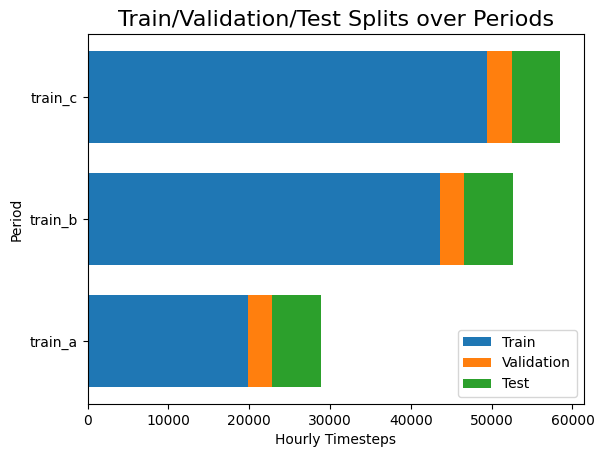

In [19]:
# Gráfico da divisão treino/val/teste
ind = np.arange(train.index.get_level_values("period").nunique())
names = sorted(train.index.get_level_values("period").unique())
width = 0.75
train_cnts = [len(df) for _, df in train.groupby("period")]
val_cnts = [len(df) for _, df in val.groupby("period")]
test_cnts = [len(df) for _, df in test.groupby("period")]

plt.barh(ind, train_cnts, width, label="Train")
plt.barh(ind, val_cnts, width, left=train_cnts, label="Validation")
plt.barh(ind, test_cnts, width, left=np.add(train_cnts, val_cnts), label="Test")
plt.yticks(ind, names)
plt.ylabel("Period")
plt.xlabel("Hourly Timesteps")
plt.title("Train/Validation/Test Splits over Periods", fontsize=16)
plt.legend()
plt.show()

# Construindo o modelo

In [20]:
data_config = {
    "timesteps": 32,   # tamanho da janela de tempo
    "batch_size": 32,  # tamanho dos lotes
}

def timeseries_dataset_from_df(df: pd.DataFrame, batch_size: int):
    """Cria um tf.data.Dataset de janelas por período (janelas nunca
    atravessam a fronteira entre períodos)."""
    dataset = None
    timesteps = data_config["timesteps"]

    for _, period_df in df.groupby("period"):
        inputs = period_df[XCOLS][:-timesteps]
        outputs = period_df[YCOLS][timesteps:]

        period_ds = preprocessing.timeseries_dataset_from_array(
            inputs, outputs, timesteps, batch_size=batch_size,
        )
        dataset = period_ds if dataset is None else dataset.concatenate(period_ds)

    return dataset

train_ds = timeseries_dataset_from_df(train, data_config["batch_size"])
val_ds = timeseries_dataset_from_df(val, data_config["batch_size"])

print(f"Number of train batches: {len(train_ds)}")
print(f"Number of val batches: {len(val_ds)}")

Number of train batches: 3522
Number of val batches: 276


In [21]:
model_config = {"n_epochs": 50, "n_neurons": 512, "dropout": 0.4, "stateful": False}

model = Sequential([
    LSTM(
        model_config["n_neurons"],
        input_shape=(data_config["timesteps"], len(XCOLS)),
        stateful=model_config["stateful"],
        dropout=model_config["dropout"],
    ),
    Dense(len(YCOLS)),
])

model.compile(
    loss="mean_squared_error",           # loss = MSE (o RMSE é calculado depois)
    optimizer=RMSprop(learning_rate=1e-3),
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 512)            │     1,081,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,082,370 (4.13 MB)

 Trainable params: 1,082,370 (4.13 MB)

 Non-trainable params: 0 (0.00 B)

# Treinando o modelo

Com callbacks: para de treinar quando a validação não melhora, salva o melhor modelo e reduz o learning rate em platôs — na V1.8 eram 15 épocas fixas, sem controle de overfitting.

In [22]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ModelCheckpoint("model.keras", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

# Obs.: quando a entrada é um tf.data.Dataset, `batch_size` no fit é ignorado
# (o batch já foi definido na criação do dataset) — por isso foi removido.
history = model.fit(
    train_ds,
    epochs=model_config["n_epochs"],
    verbose=1,
    shuffle=False,
    validation_data=val_ds,
    callbacks=callbacks,
)

Epoch 1/50
3522/3522 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - loss: 218.8797 - val_loss: 501.1866 - learning_rate: 0.0010
Epoch 2/50
3522/3522 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 181.3556 - val_loss: 443.0571 - learning_rate: 0.0010
Epoch 3/50
3522/3522 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - loss: 171.3095 - val_loss: 429.6626 - learning_rate: 0.0010
Epoch 4/50
3522/3522 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - loss: 168.3821 - val_loss: 405.5516 - learning_rate: 0.0010
Epoch 5/50
3522/3522 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 162.1504 - val_loss: 397.9086 - learning_rate: 0.0010
Epoch 6/50
3522/3522 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - loss: 160.5425 - val_loss: 391.4354 - learning_rate: 0.0010
Epoch 7/50
3522/3522 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - loss: 161.0958 - val_loss: 386.5609 - learning_rate: 0.0010
Epoch 8/50
3522/3522 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 158.3189 - val_loss: 386.7711 - learning_rate: 0.0010
Epoch 9/50
3522/3522 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step 

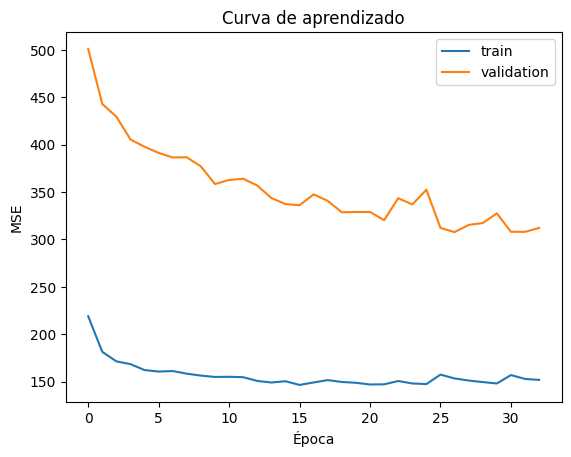

In [23]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")  # era 'test' na V1.8 (errado)
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Curva de aprendizado")
plt.legend()
plt.show()

# Avaliação no teste

In [24]:
test_ds = timeseries_dataset_from_df(test, data_config["batch_size"])
mse = model.evaluate(test_ds)
print(f"Test RMSE: {mse ** 0.5:.2f}")

558/558 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 294.2475
Test RMSE: 17.15


# Serialização (modelo + scaler + config)

In [25]:
model.save("model.keras")

with open("scaler.pck", "wb") as f:
    pickle.dump(scaler, f)

data_config["solar_wind_subset"] = SOLAR_WIND_FEATURES
print(data_config)
with open("config.json", "w") as f:
    json.dump(data_config, f)

{'timesteps': 32, 'batch_size': 32, 'solar_wind_subset': ['bt', 'temperature', 'bx_gse', 'by_gse', 'bz_gse', 'speed', 'density']}


# Inferência

Reutiliza **as mesmas funções** do pipeline (na V1.8 tudo era redefinido aqui, com pequenas diferenças — receita para bugs silenciosos entre treino e produção).

In [26]:
# Carregar artefatos serializados
import keras

model = keras.models.load_model("model.keras")

with open("config.json", "r") as f:
    CONFIG = json.load(f)
with open("scaler.pck", "rb") as f:
    scaler = pickle.load(f)

TIMESTEPS = CONFIG["timesteps"]


def predict_dst(
    solar_wind_7d: pd.DataFrame,
    satellite_positions_7d: pd.DataFrame,
    latest_sunspot_number: float,
) -> Tuple[float, float]:
    """Usa os dados até t-1 para prever o Dst em t (t0) e t+1h (t1).

    Parâmetros
    ----------
    solar_wind_7d : últimos 7 dias de vento solar até (t - 1) min
    satellite_positions_7d : últimos 7 dias de posição do satélite (não usado
        pelo modelo atual; mantido pela assinatura exigida)
    latest_sunspot_number : último SSN mensal disponível
    """
    sunspot_df = pd.DataFrame(
        {"smoothed_ssn": latest_sunspot_number},
        index=pd.to_timedelta(solar_wind_7d.index).floor("h").unique(),
    )

    hourly = build_hourly_features(
        solar_wind_7d, sunspot_df, subset=CONFIG["solar_wind_subset"]
    )
    features = impute_features(scale_features(hourly[XCOLS], scaler))

    # len(XCOLS) em vez de features.shape[1]: na V1.8 o reshape quebraria
    # se `features` ganhasse qualquer coluna extra
    model_input = (
        features[XCOLS]
        .iloc[-TIMESTEPS:]
        .values
        .reshape((1, TIMESTEPS, len(XCOLS)))
    )

    prediction_at_t0, prediction_at_t1 = model.predict(model_input, verbose=0)[0]
    # a competição exige previsões entre -2000 e 500
    return (
        float(np.clip(prediction_at_t0, -2000, 500)),
        float(np.clip(prediction_at_t1, -2000, 500)),
    )

Previsão t0: -5.76 nT | t1: -5.59 nT


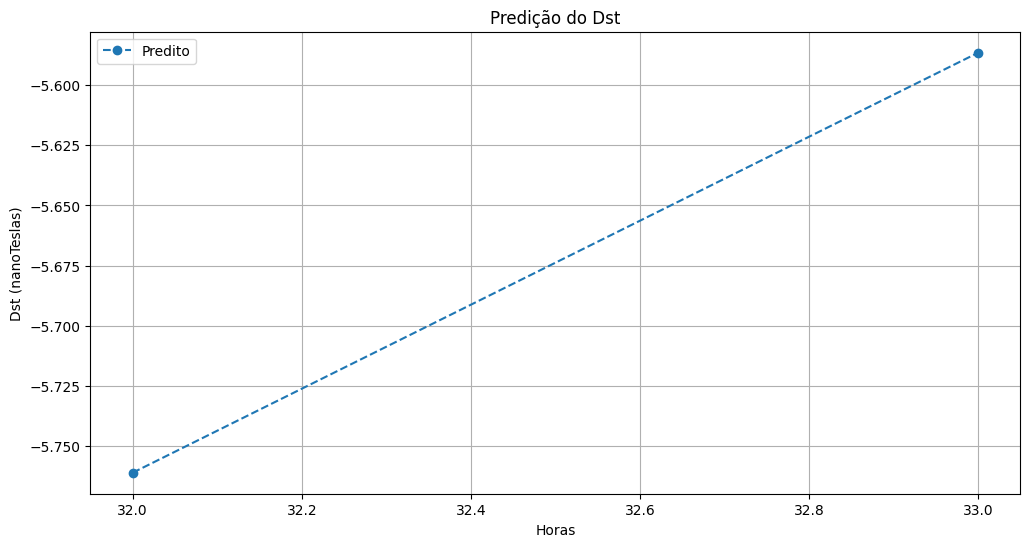

In [27]:
# Exemplo de uso
solar_wind_7d = pd.read_csv(DATA_DIR / "solar_wind.csv", index_col="timedelta")
satellite_positions_7d = pd.read_csv(DATA_DIR / "satellite_pos.csv", index_col="timedelta")
latest_sunspot_number = 150

t0, t1 = predict_dst(solar_wind_7d, satellite_positions_7d, latest_sunspot_number)
print(f"Previsão t0: {t0:.2f} nT | t1: {t1:.2f} nT")

plt.figure(figsize=(12, 6))
plt.plot(np.arange(32, 34), [t0, t1], label="Predito", marker="o", linestyle="--")
plt.xlabel("Horas")
plt.ylabel("Dst (nanoTeslas)")
plt.title("Predição do Dst")
plt.legend()
plt.grid(True)
plt.show()